# Data Preprocessing
**Date:** May 20, 2026

## Machine Learning for Linear Regression, Random Forest & Gradient Boosting

### Load Original Dataset

In [1]:
import pandas as pd
raw_df = pd.read_csv('stock_datasets/RELIANCE.csv')

### Create Working Copy

In [2]:
df = raw_df.copy()

### Inspect Dataset

In [3]:
print(df.head())
print(df.info())
print(df.shape)
print(df.dtypes)

         Date        Open        High         Low       Close    Volume
0  2015-01-01  189.657416  190.877140  189.090335  189.999786   2963643
1  2015-01-02  190.042601  191.743813  189.229456  189.496933   7331366
2  2015-01-05  189.379224  190.641759  187.046752  187.421234  10103941
3  2015-01-06  186.169433  186.811392  178.037884  178.915237  18627980
4  2015-01-07  179.129214  183.772746  179.107815  182.809799  20720312
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2786 entries, 0 to 2785
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2786 non-null   object 
 1   Open    2786 non-null   float64
 2   High    2786 non-null   float64
 3   Low     2786 non-null   float64
 4   Close   2786 non-null   float64
 5   Volume  2786 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 130.7+ KB
None
(2786, 6)
Date       object
Open      float64
High      float64
Low       float64
Close     float

### Check Missing Values

In [4]:
print(df.isnull().sum())

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


### Remove Missing Values

In [5]:
df.dropna(inplace=True)

### Check Duplicate Rows

In [6]:
print(df.duplicated().sum())

0


### Remove Duplicate Rows

In [7]:
df.drop_duplicates(inplace=True)

### Convert Date Column — Convert Date from object/string to datetime

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

### Sort Data Chronologically — important for stock prediction

In [9]:
df = df.sort_values(by="Date")
df = df.reset_index(drop=True)

### Create Date Features — Extract useful numerical features from Date

In [10]:
df["Year"]      = df["Date"].dt.year
df["Month"]     = df["Date"].dt.month
df["Day"]       = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

### Drop Original Date Column — After extracting features, remove raw Date column

In [11]:
df.drop(columns=["Date"], inplace=True)

### Check New Dataset Column

In [12]:
df.head()

,Open,High,Low,Close,Volume,Year,Month,Day,DayOfWeek
0,189.657416,190.877140,189.090335,189.999786,2963643,2015,1,1,3
1,190.042601,191.743813,189.229456,189.496933,7331366,2015,1,2,4
2,189.379224,190.641759,187.046752,187.421234,10103941,2015,1,5,0
3,186.169433,186.811392,178.037884,178.915237,18627980,2015,1,6,1
4,179.129214,183.772746,179.107815,182.809799,20720312,2015,1,7,2


### Keep Required Columns Only

In [13]:
df = df[[
    "Open", "High", "Low", "Close", "Volume",
    "Year", "Month", "Day", "DayOfWeek"
]]

### Volume Log Transform

Volume ranges from ~2.9 M to ~30 M while price features sit in the 180–1 600 INR range. This 10 000× difference would dominate distance calculations and shrink the Linear Regression Volume coefficient to near-zero. A `log1p` transform compresses the skewed distribution and brings Volume into a comparable magnitude before scaling.

In [14]:
import numpy as np

df['Volume'] = np.log1p(df['Volume'])
print('Volume after log1p transform:')
print(df['Volume'].describe().round(4))

Volume after log1p transform:
count    2786.0000
mean       16.5116
std         0.7009
min         0.0000
25%        16.1437
50%        16.4645
75%        16.8291
max        18.7761
Name: Volume, dtype: float64


### Create Return Feature

In [15]:
df["Return"] = df["Close"].pct_change()

### Create Moving Averages

In [16]:
df["MA10"] = df["Close"].rolling(10).mean()
df["MA50"] = df["Close"].rolling(50).mean()

### Create Volatility Feature

In [17]:
df["Volatility"] = df["Return"].rolling(10).std()

### Create Momentum Feature

In [18]:
df["Momentum"] = df["Close"] - df["Close"].shift(10)

### Create Lag Features — important for stock prediction

In [19]:
df["Lag1"] = df["Close"].shift(1)
df["Lag2"] = df["Close"].shift(2)
df["Lag3"] = df["Close"].shift(3)

### Create Price Range Feature

In [20]:
df["Range"] = df["High"] - df["Low"]

### Create EMA Feature

In [21]:
df["EMA10"] = df["Close"].ewm(span=10).mean()

### Create RSI Feature

RSI is calculated using Wilder's exponential moving average (`com=13`, equivalent to `alpha = 1/14`). This is the standard RSI formula as defined by J. Welles Wilder (1978). Using a simple `rolling().mean()` instead produces a non-standard RSI that can deviate 5–15 points per timestep from the correct value.

In [22]:
delta    = df['Close'].diff()
gain     = delta.where(delta > 0, 0.0)
loss     = -delta.where(delta < 0, 0.0)

# Wilder's smoothing: com=13 is equivalent to alpha=1/14
avg_gain = gain.ewm(com=13, min_periods=14).mean()
avg_loss = loss.ewm(com=13, min_periods=14).mean()

rs        = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

print('RSI sample (should be bounded 0–100):')
print(df['RSI'].dropna().describe().round(2))

RSI sample (should be bounded 0–100):
count    2773.00
mean       52.98
std        12.01
min        16.99
25%        44.16
50%        52.72
75%        62.00
max        84.45
Name: RSI, dtype: float64


### Create Target Variable — Predict next-day closing price

In [23]:
df["Target"] = df["Close"].shift(-1)

### Remove Generated NaN Values — Rolling and shifting create NaN rows

In [24]:
df.dropna(inplace=True)

### Final Dataset Validation

In [25]:
print(df.info())
print(df.isnull().sum())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 2736 entries, 49 to 2784
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Open        2736 non-null   float64
 1   High        2736 non-null   float64
 2   Low         2736 non-null   float64
 3   Close       2736 non-null   float64
 4   Volume      2736 non-null   float64
 5   Year        2736 non-null   int32  
 6   Month       2736 non-null   int32  
 7   Day         2736 non-null   int32  
 8   DayOfWeek   2736 non-null   int32  
 9   Return      2736 non-null   float64
 10  MA10        2736 non-null   float64
 11  MA50        2736 non-null   float64
 12  Volatility  2736 non-null   float64
 13  Momentum    2736 non-null   float64
 14  Lag1        2736 non-null   float64
 15  Lag2        2736 non-null   float64
 16  Lag3        2736 non-null   float64
 17  Range       2736 non-null   float64
 18  EMA10       2736 non-null   float64
 19  RSI         2736 non-null   flo

### Save Processed Dataset

In [26]:
df.to_csv("stock_datasets/RELIANCE_processed.csv", index=False)

### Feature Correlation Analysis

Pearson correlation of every feature against the Target (next-day Close) reveals which features carry the most signal. Inter-feature correlation highlights multicollinearity risk for Linear Regression — features with very high mutual correlation (r > 0.95) contribute redundant information.

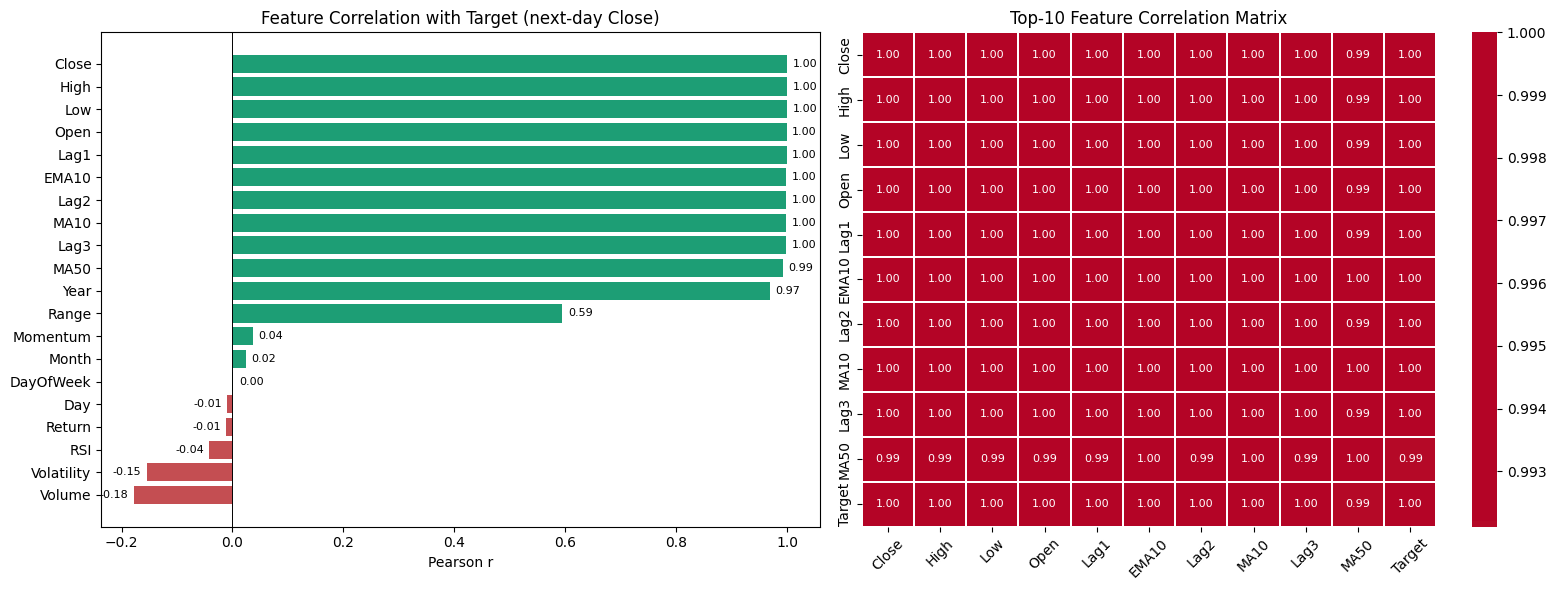

Heatmap saved.


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

corr        = df.corr()
target_corr = corr['Target'].drop('Target').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: feature-target correlation bar
colors = ['#C44E52' if v < 0 else '#1D9E75' for v in target_corr]
axes[0].barh(target_corr.index, target_corr.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.7)
axes[0].set_title('Feature Correlation with Target (next-day Close)')
axes[0].set_xlabel('Pearson r')
for i, v in enumerate(target_corr.values):
    axes[0].text(
        v + (0.01 if v >= 0 else -0.01), i,
        f'{v:.2f}', va='center',
        ha='left' if v >= 0 else 'right', fontsize=8
    )

# Right: full heatmap of top correlated features
top_features = target_corr.abs().nlargest(10).index.tolist() + ['Target']
sns.heatmap(
    df[top_features].corr(), annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=axes[1],
    annot_kws={'size': 8}, linewidths=0.3
)
axes[1].set_title('Top-10 Feature Correlation Matrix')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('stock_datasets/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved.')

### Feature Scaling — StandardScaler

Even after the log transform, Volume (~16.8 mean) and price features (~1 200 INR) still differ in scale. `StandardScaler` (zero mean, unit variance) is fitted **only on the training split** to ensure no data leakage — the test split is transformed using the training statistics. The fitted scaler is saved with `joblib` so `Model_Implementation.ipynb` can load it directly without refitting.

In [28]:
from sklearn.preprocessing import StandardScaler
import joblib

feature_cols = [c for c in df.columns if c != 'Target']
X = df[feature_cols]
y = df['Target']

# Chronological 80/20 split — same ratio used in Model Implementation
split_idx    = int(len(df) * 0.8)
X_train_raw  = X.iloc[:split_idx]
X_test_raw   = X.iloc[split_idx:]

# Fit ONLY on training data
scaler_ml    = StandardScaler()
X_train_sc   = scaler_ml.fit_transform(X_train_raw)
X_test_sc    = scaler_ml.transform(X_test_raw)

joblib.dump(scaler_ml, 'stock_datasets/scaler_ml.pkl')
print('StandardScaler saved to stock_datasets/scaler_ml.pkl')
print(f'X_train_scaled shape : {X_train_sc.shape}')
print(f'X_test_scaled  shape : {X_test_sc.shape}')
print(f'Feature means (train, should be ~0): {X_train_sc.mean(axis=0).round(3)}')

StandardScaler saved to stock_datasets/scaler_ml.pkl
X_train_scaled shape : (2188, 20)
X_test_scaled  shape : (548, 20)
Feature means (train, should be ~0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.  0.  0. -0.  0.  0. -0.  0. -0.  0.
 -0. -0.]


### Train/Test Split Visualisation

Plotting the 80/20 chronological split on the Close price chart shows which time period each model trains on vs. tests on, and highlights structural differences between the two regimes.

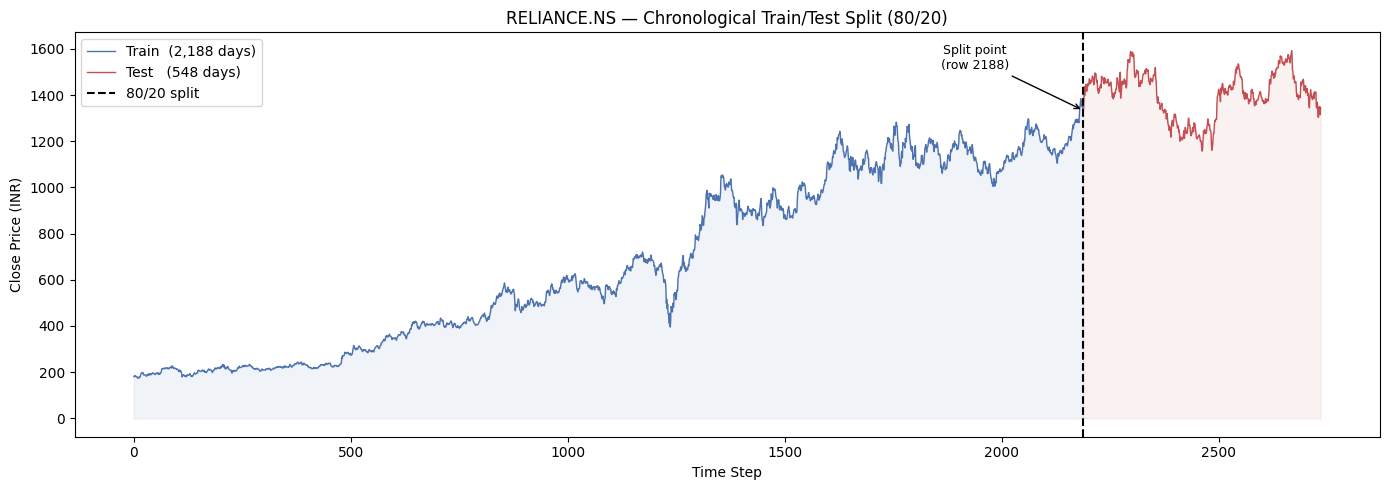

Split plot saved.


In [29]:
split_idx   = int(len(df) * 0.8)
train_close = df['Close'].iloc[:split_idx]
test_close  = df['Close'].iloc[split_idx:]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(range(len(train_close)), train_close.values,
        color='#4C72B0', linewidth=1,
        label=f'Train  ({len(train_close):,} days)')
ax.plot(range(len(train_close), len(df)), test_close.values,
        color='#C44E52', linewidth=1,
        label=f'Test   ({len(test_close):,} days)')
ax.axvline(x=split_idx, color='black', linewidth=1.5,
           linestyle='--', label='80/20 split')
ax.fill_between(range(len(train_close)),
                train_close.values, alpha=0.08, color='#4C72B0')
ax.fill_between(range(len(train_close), len(df)),
                test_close.values, alpha=0.08, color='#C44E52')

ax.annotate(
    f'Split point\n(row {split_idx})',
    xy=(split_idx, df['Close'].iloc[split_idx]),
    xytext=(split_idx - 250, df['Close'].max() * 0.95),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9, ha='center'
)

ax.set_title('RELIANCE.NS — Chronological Train/Test Split (80/20)')
ax.set_xlabel('Time Step')
ax.set_ylabel('Close Price (INR)')
ax.legend()
plt.tight_layout()
plt.savefig('stock_datasets/train_test_split_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Split plot saved.')

## Deep Learning for LSTM

### Create New Copy

In [30]:
lstm_df = raw_df.copy()

### Inspect Dataset

In [31]:
print(lstm_df.head())
print(lstm_df.info())

         Date        Open        High         Low       Close    Volume
0  2015-01-01  189.657416  190.877140  189.090335  189.999786   2963643
1  2015-01-02  190.042601  191.743813  189.229456  189.496933   7331366
2  2015-01-05  189.379224  190.641759  187.046752  187.421234  10103941
3  2015-01-06  186.169433  186.811392  178.037884  178.915237  18627980
4  2015-01-07  179.129214  183.772746  179.107815  182.809799  20720312
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2786 entries, 0 to 2785
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2786 non-null   object 
 1   Open    2786 non-null   float64
 2   High    2786 non-null   float64
 3   Low     2786 non-null   float64
 4   Close   2786 non-null   float64
 5   Volume  2786 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 130.7+ KB
None


### Handle Missing Values

In [32]:
print(lstm_df.isnull().sum())
lstm_df.dropna(inplace=True)

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


### Remove Duplicate Rows

In [33]:
print(lstm_df.duplicated().sum())
lstm_df.drop_duplicates(inplace=True)

0


### Convert Date Column

In [34]:
lstm_df["Date"] = pd.to_datetime(lstm_df["Date"])

### Sort Chronologically — IMPORTANT for LSTM

In [35]:
lstm_df = lstm_df.sort_values(by="Date")
lstm_df = lstm_df.reset_index(drop=True)

### Keep Required Columns

In [36]:
lstm_df = lstm_df[["Date", "Close"]]

### Save Unscaled Backup

In [37]:
lstm_df.to_csv(
    "stock_datasets/RELIANCE_lstm_unscaled.csv",
    index=False
)

### Scale Data — LSTM requires scaling; without scaling training is unstable

MinMaxScaler compresses all values to [0, 1]. The fitted scaler is saved with `joblib` so evaluation and inference always use the identical scaler that was fitted during preprocessing — no fragile refitting required.

In [38]:
from sklearn.preprocessing import MinMaxScaler
import joblib

scaler      = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(lstm_df[['Close']])

joblib.dump(scaler, 'stock_datasets/scaler_lstm.pkl')
print('LSTM MinMaxScaler saved to stock_datasets/scaler_lstm.pkl')
print(f'Scale range: [{scaler.data_min_[0]:.2f}, {scaler.data_max_[0]:.2f}] INR')

LSTM MinMaxScaler saved to stock_datasets/scaler_lstm.pkl
Scale range: [173.49, 1592.30] INR


### Create Sequence Windows — MOST IMPORTANT LSTM preprocessing step

LSTM learns from sequences of previous timesteps. A sliding window of 60 days means the model sees 60 consecutive daily closing prices to predict day 61.

In [39]:
import numpy as np

X_lstm, y_lstm = [], []
window_size = 60

for i in range(window_size, len(scaled_data)):
    X_lstm.append(scaled_data[i-window_size:i])
    y_lstm.append(scaled_data[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

### Check Shapes

In [40]:
print(X_lstm.shape)
print(y_lstm.shape)

(2726, 60, 1)
(2726, 1)


### Train-Test Split — For time-series: NO SHUFFLING

In [41]:
split = int(len(X_lstm) * 0.8)

X_train = X_lstm[:split]
X_test  = X_lstm[split:]
y_train = y_lstm[:split]
y_test  = y_lstm[split:]

### Check Split Shapes

In [42]:
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (2180, 60, 1)
X_test : (546, 60, 1)
y_train: (2180, 1)
y_test : (546, 1)


### Save Processed Arrays

In [43]:
np.save('stock_datasets/X_train.npy', X_train)
np.save('stock_datasets/X_test.npy',  X_test)
np.save('stock_datasets/y_train.npy', y_train)
np.save('stock_datasets/y_test.npy',  y_test)
print('All LSTM arrays saved.')

All LSTM arrays saved.
